## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

In [2]:
import requests

# Coordenadas de Kuna en Bilbao
latitude = 43.2540
longitude = -2.9230
temper = 'temperature_2m'

url = f"https://api.open-meteo.com/v1/forecast?"  # Aquí vienen el resto de los parámetros

url_loc = url + '&latitude=' + str(latitude) + '&longitude=' + str(longitude) + '&hourly=' + temper

response = requests.get(url_loc)
response.json()['hourly']
# url_loc

{'time': ['2026-03-26T00:00',
  '2026-03-26T01:00',
  '2026-03-26T02:00',
  '2026-03-26T03:00',
  '2026-03-26T04:00',
  '2026-03-26T05:00',
  '2026-03-26T06:00',
  '2026-03-26T07:00',
  '2026-03-26T08:00',
  '2026-03-26T09:00',
  '2026-03-26T10:00',
  '2026-03-26T11:00',
  '2026-03-26T12:00',
  '2026-03-26T13:00',
  '2026-03-26T14:00',
  '2026-03-26T15:00',
  '2026-03-26T16:00',
  '2026-03-26T17:00',
  '2026-03-26T18:00',
  '2026-03-26T19:00',
  '2026-03-26T20:00',
  '2026-03-26T21:00',
  '2026-03-26T22:00',
  '2026-03-26T23:00',
  '2026-03-27T00:00',
  '2026-03-27T01:00',
  '2026-03-27T02:00',
  '2026-03-27T03:00',
  '2026-03-27T04:00',
  '2026-03-27T05:00',
  '2026-03-27T06:00',
  '2026-03-27T07:00',
  '2026-03-27T08:00',
  '2026-03-27T09:00',
  '2026-03-27T10:00',
  '2026-03-27T11:00',
  '2026-03-27T12:00',
  '2026-03-27T13:00',
  '2026-03-27T14:00',
  '2026-03-27T15:00',
  '2026-03-27T16:00',
  '2026-03-27T17:00',
  '2026-03-27T18:00',
  '2026-03-27T19:00',
  '2026-03-27T20:00',
  

In [3]:
import json

data = response.json()['hourly']

with open('meteo_data.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4, ensure_ascii=False)

In [4]:
import pandas as pd

df = pd.read_json('meteo_data.json')
df

,time,temperature_2m
0,2026-03-26T00:00,10.6
1,2026-03-26T01:00,10.2
2,2026-03-26T02:00,9.9
3,2026-03-26T03:00,9.1
4,2026-03-26T04:00,9.4
...,...,...
163,2026-04-01T19:00,12.5
164,2026-04-01T20:00,11.8
165,2026-04-01T21:00,11.2
166,2026-04-01T22:00,10.9


In [5]:
df[['año','mes', 'datos']] = df['time'].str.split('-', n=2, expand=True)
df[['dia', 'hora']] = df['datos'].str.split('T', n=1, expand=True)
df.pop('time')
df

,temperature_2m,año,mes,datos,dia,hora
0,10.6,2026,03,26T00:00,26,00:00
1,10.2,2026,03,26T01:00,26,01:00
2,9.9,2026,03,26T02:00,26,02:00
3,9.1,2026,03,26T03:00,26,03:00
4,9.4,2026,03,26T04:00,26,04:00
...,...,...,...,...,...,...
163,12.5,2026,04,01T19:00,01,19:00
164,11.8,2026,04,01T20:00,01,20:00
165,11.2,2026,04,01T21:00,01,21:00
166,10.9,2026,04,01T22:00,01,22:00


In [15]:
meteo = df.drop(['año', 'mes', 'datos', 'dia'], axis=1)
meteo.rename(columns={'temperature_2m': 'temp'}, inplace=True)
meteo

,temp,hora
0,10.6,00:00
1,10.2,01:00
2,9.9,02:00
3,9.1,03:00
4,9.4,04:00
...,...,...
163,12.5,19:00
164,11.8,20:00
165,11.2,21:00
166,10.9,22:00


<Axes: xlabel='hora', ylabel='temp'>

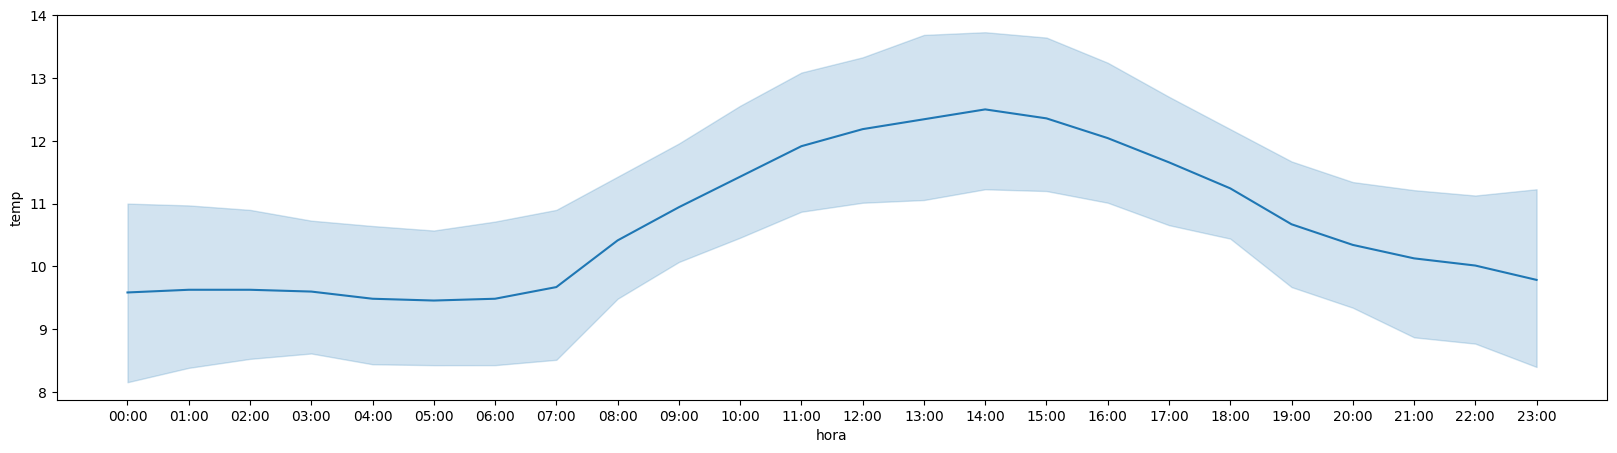

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert hora to proper datetime for better plotting
# meteo['hora'] = pd.to_datetime(meteo['hora'])

plt.figure(figsize=(20, 5))
sns.lineplot(x=meteo['hora'], y=meteo['temp'])